# 导入库

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [2]:
data = load_breast_cancer()
X = data.data # 特征矩阵：所有样本的特征数据
y = data.target # 标签向量：所有样本对应的类别标签
print("数据形状: X=" + str(X.shape) + ", y=" + str(y.shape))
print("类别分布: 恶性=" + str(np.sum(y==0)) + ", 良性=" + str(np.sum(y==1)))
print("良性比例: " + str(round(100*np.sum(y==1)/len(y), 1)) + "%")

数据形状: X=(569, 30), y=(569,)
类别分布: 恶性=212, 良性=357
良性比例: 62.7%


# 划分测试集与训练集

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("训练集: " + str(X_train.shape[0]) + " 个样本")
print("测试集: " + str(X_test.shape[0]) + " 个样本")

训练集: 455 个样本
测试集: 114 个样本


# 训练逻辑回归模型

In [9]:
model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
print("模型训练完成")
print("迭代次数: " + str(model.n_iter_[0]))
print("最重要的5个特征及其权重:")
top5_idx = np.argsort(np.abs(model.coef_[0]))[-5:][::-1]
# model.coef_[0]获取模型学到的权重系数，形状为(30,)，对应30个特征
# np.argsort(...) 返回按绝对值从小到大排序的索引
for idx in top5_idx:
    feature_name = data.feature_names[idx][:20].ljust(20)
    coef_value = model.coef_[0][idx] #权重
    print("  " + feature_name + ": " + str(round(coef_value, 4)))

模型训练完成
迭代次数: 19
最重要的5个特征及其权重:
  worst texture       : -1.2551
  radius error        : -1.083
  worst concave points: -0.9537
  worst area          : -0.9478
  worst radius        : -0.9476


# 模型预测与评估

In [18]:
# 使用训练好的模型对标准化后的测试集特征进行预测
# 这里预测的是类别（0或1），使用默认阈值0.5
y_pred = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
# predict_proba返回一个二维数组，形状为[n_samples, n_classes]
print("测试集前5个样本预测:")
print("真实标签 | 预测标签 | 良性概率")
for i in range(5):
    print("    " + str(y_test[i]) + "     |     " + str(y_pred[i]) + "     |   " + str(round(y_pred_prob[i], 3)))

测试集前5个样本预测:
真实标签 | 预测标签 | 良性概率
    0     |     0     |   0.0
    1     |     1     |   1.0
    0     |     0     |   0.006
    1     |     1     |   0.534
    0     |     0     |   0.0


In [12]:
accuracy = accuracy_score(y_test, y_pred)
conf_mat = confusion_matrix(y_test, y_pred)
print("准确率: " + str(round(accuracy, 4)))
print("混淆矩阵:")
print("        预测0  预测1")
print("真实0    " + str(conf_mat[0, 0]) + "     " + str(conf_mat[0, 1]))
print("真实1    " + str(conf_mat[1, 0]) + "     " + str(conf_mat[1, 1]))
TN, FP, FN, TP = conf_mat.ravel()
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
print("详细指标:")
print("精确率(查准): " + str(round(precision, 4)))
print("召回率(查全): " + str(round(recall, 4)))
print("F1分数: " + str(round(f1, 4)))
auc_score = roc_auc_score(y_test, y_pred_prob)
print("AUC值: " + str(round(auc_score, 4))) #AUC（Area Under the ROC Curve，ROC曲线下面积）是评估二分类模型性能的核心指标，范围在0到1之间
print("简要分类报告:")
print(classification_report(y_test, y_pred, target_names=['恶性', '良性'], digits=4))

准确率: 0.9825
混淆矩阵:
        预测0  预测1
真实0    41     1
真实1    1     71
详细指标:
精确率(查准): 0.9861
召回率(查全): 0.9861
F1分数: 0.9861
AUC值: 0.9954
简要分类报告:
              precision    recall  f1-score   support

          恶性     0.9762    0.9762    0.9762        42
          良性     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



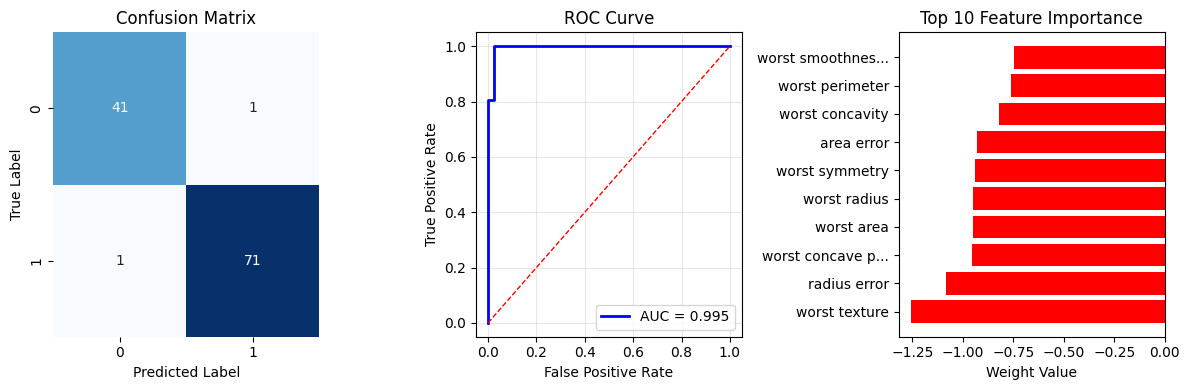

关键指标：准确率 98.2%，AUC值 0.995


In [17]:
plt.figure(figsize=(12, 4))
# 子图1：混淆矩阵热图
plt.subplot(1, 3, 1)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')  
plt.ylabel('True Label')       
# 子图2：ROC曲线
plt.subplot(1, 3, 2)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob) #（tpr真阳性率 / 召回率，fpr假阳性率）
plt.plot(fpr, tpr, 'b-', linewidth=2, label='AUC = ' + str(round(auc_score, 3)))
plt.plot([0, 1], [0, 1], 'r--', linewidth=1)
plt.xlabel('False Positive Rate')  
plt.ylabel('True Positive Rate')   
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
# 子图3：特征重要性
plt.subplot(1, 3, 3)
top10_idx = np.argsort(np.abs(model.coef_[0]))[-10:][::-1]
top10_names = [data.feature_names[i][:15] + '...' if len(data.feature_names[i]) > 15 else data.feature_names[i] for i in top10_idx]
top10_weights = model.coef_[0][top10_idx]
colors = ['red' if w < 0 else 'green' for w in top10_weights]
plt.barh(range(10), top10_weights, color=colors)
plt.yticks(range(10), top10_names)
plt.xlabel('Weight Value')  
plt.title('Top 10 Feature Importance')
plt.tight_layout()
plt.show()
print("关键指标：准确率 " + str(round(100*accuracy, 1)) + "%，AUC值 " + str(round(auc_score, 3)))

数据集信息:
总样本数: 569
特征数: 30
恶性样本数: 212
良性样本数: 357



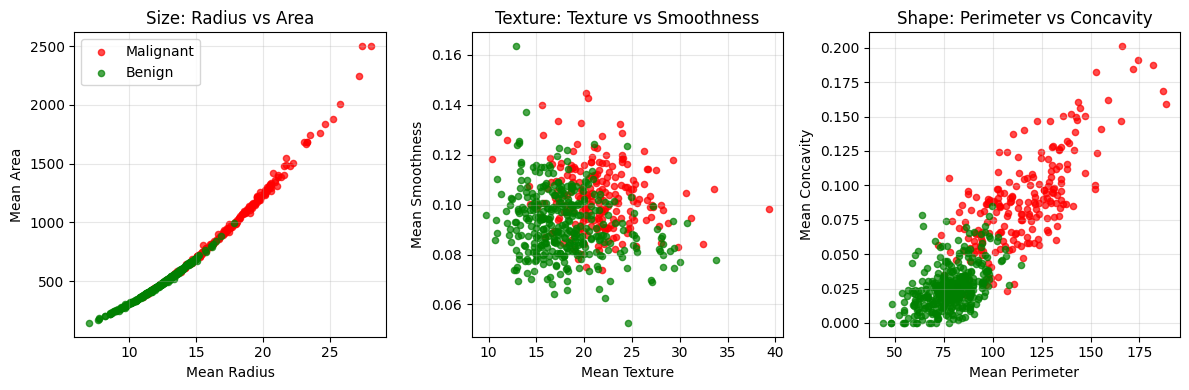

In [20]:
malignant = X[y == 0]  # 恶性样本
benign = X[y == 1]     # 良性样本
print("数据集信息:")
print("总样本数:", X.shape[0])
print("特征数:", X.shape[1])
print("恶性样本数:", malignant.shape[0])
print("良性样本数:", benign.shape[0])
print()
# 创建散点图
plt.figure(figsize=(12, 4))
# 子图1：半径 vs 面积
plt.subplot(1, 3, 1)
plt.scatter(malignant[:, 0], malignant[:, 3], alpha=0.7, c='red', s=20, label='Malignant')
plt.scatter(benign[:, 0], benign[:, 3], alpha=0.7, c='green', s=20, label='Benign')
plt.xlabel('Mean Radius')
plt.ylabel('Mean Area')
plt.title('Size: Radius vs Area')
plt.legend()
plt.grid(True, alpha=0.3)
# 子图2：纹理 vs 平滑度
plt.subplot(1, 3, 2)
plt.scatter(malignant[:, 1], malignant[:, 4], alpha=0.7, c='red', s=20)
plt.scatter(benign[:, 1], benign[:, 4], alpha=0.7, c='green', s=20)
plt.xlabel('Mean Texture')
plt.ylabel('Mean Smoothness')
plt.title('Texture: Texture vs Smoothness')
plt.grid(True, alpha=0.3)
# 子图3：周长 vs 凹度
plt.subplot(1, 3, 3)
plt.scatter(malignant[:, 2], malignant[:, 7], alpha=0.7, c='red', s=20)
plt.scatter(benign[:, 2], benign[:, 7], alpha=0.7, c='green', s=20)
plt.xlabel('Mean Perimeter')
plt.ylabel('Mean Concavity')
plt.title('Shape: Perimeter vs Concavity')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()